In [13]:
# Purchase Likelihood — data load, preprocessing, and modeling
# Loads the synthetic dataset and fits a separate LightGBM classifier
# for each purchase window: 1d and 7d only.

import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score
)
from joblib import dump
from lightgbm import LGBMClassifier

# sklearn OneHotEncoder compatibility: import here but instantiate conditionally
from sklearn.preprocessing import OneHotEncoder

# CONFIG
CSV_PATH = Path("..") / ".." / "Dataset" / "synthetic_prophet_dataset_v2b.csv"
if not CSV_PATH.exists():
    CSV_PATH = Path("Dataset") / "synthetic_prophet_dataset_v2b.csv"

# Default SAMPLE_N reduced for quicker runs; set to None to use full dataset
SAMPLE_N = None
SEED = 2025
OUTPUT_DIR = Path(".") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Provided train-window positive rates (use these to compute class weighting)
# These are the rates you supplied (positives / N):
label_rate_map = {
    'purchase_next_1d': 0.0406,
    'purchase_next_7d': 0.2103,
    'purchase_next_30d': 0.491,
    'purchase_next_90d': 0.752,
    'churn_30d': 0.0968,
}

print('Using CSV:', CSV_PATH)

# Load
use_kwargs = {}
if SAMPLE_N is not None:
    use_kwargs["nrows"] = SAMPLE_N

df = pd.read_csv(CSV_PATH, parse_dates=["anchor_time"], **use_kwargs)
print('Loaded rows:', len(df))

# Ensure temporal ordering for time-based splits
df = df.sort_values('anchor_time').reset_index(drop=True)

# Confirm identity column is not used as feature
if 'person' not in df.columns:
    print('Warning: `person` column not found in dataset')
else:
    print('`person` column present; it will be excluded from features (identity dropped)')

# Target labels to model — restrict to 1d and 7d as requested
label_cols = [c for c in [
    'purchase_next_1d','purchase_next_7d'
] if c in df.columns]
print('Labels found:', label_cols)

# Basic preprocessing and feature selection
# Drop identifier/time columns and label columns to form feature set
# Keep `anchor_time` in df for temporal splitting, but exclude from features
drop_cols = ['person'] + label_cols + ['clv_next_90d','churn_30d','ad_exposure_next7','true_uplift']
candidate_features = [c for c in df.columns if c not in drop_cols and c != 'anchor_time']
print('Candidate features count:', len(candidate_features))

# Split features by dtype
numeric_features = [c for c in candidate_features if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in candidate_features if c not in numeric_features]
print('Numeric features:', len(numeric_features), 'Categorical features:', len(categorical_features))

# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale", StandardScaler()),
])

# OneHotEncoder compatibility: some sklearn versions use `sparse`, newer use `sparse_output`
try:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='constant', fill_value='missing')),
    ("ohe", ohe_instance)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features),
    ],
    remainder='drop'
)

# Create temporal train/val/test indices (70/15/15 by time)
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
# ensure at least one sample in each split
n_val = max(n_val, 1)
if n - (n_train + n_val) < 1:
    # reduce train to ensure test has at least one
    n_train = max(n - n_val - 1, 1)

train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_train + n_val)
test_idx = np.arange(n_train + n_val, n)
print(f'Temporal split sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

# Training loop for each label
results = {}
for label in label_cols:
    print('\n--- Training for label:', label, '---')
    # Prepare X,y
    X = df[candidate_features].copy()
    y = df[label].astype(int).copy()

    # quick sanity: if label is constant, skip
    if y.nunique() <= 1:
        print('Skipping', label, '- only one class present')
        continue

    # temporal split (no randomness)
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)

    # fit preprocessor on training data and transform
    preprocessor.fit(X_train)
    X_train_t = preprocessor.transform(X_train)
    X_val_t = preprocessor.transform(X_val)
    X_test_t = preprocessor.transform(X_test)

    # compute scale_pos_weight for this label using provided rates
    rate = label_rate_map.get(label)
    if rate is None:
        # fallback: compute empirical rate from training set
        emp_rate = float(y_train.mean()) if len(y_train)>0 else 0.5
        print(f'No provided rate for {label}; using empirical train rate {emp_rate:.4f} to derive weights')
        rate = emp_rate

    if rate <= 0:
        scale_pos_weight = 1.0
    else:
        scale_pos_weight = float((1.0 - rate) / rate)

    print(f'Using scale_pos_weight={scale_pos_weight:.4f} for label {label} (rate={rate:.4f})')

    # model using LightGBM trained on preprocessed arrays so eval_set works correctly
    clf = LGBMClassifier(
        n_estimators=200,
        objective='binary',
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        class_weight=None
    )

    # fit with early stopping on validation set
    try:
        clf.fit(
            X_train_t, y_train,
            eval_set=[(X_val_t, y_val)],
            early_stopping_rounds=50,
            verbose=False
        )
    except TypeError:
        # some lightgbm versions expect `callbacks` instead; fall back to simpler fit
        clf.fit(X_train_t, y_train)

    # predict on test
    y_pred = clf.predict(X_test_t)
    try:
        y_proba = clf.predict_proba(X_test_t)[:,1]
    except Exception:
        y_proba = None

    # metrics
    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_test, y_pred))
    metrics['precision'] = float(precision_score(y_test, y_pred, zero_division=0))
    metrics['recall'] = float(recall_score(y_test, y_pred, zero_division=0))
    metrics['f1'] = float(f1_score(y_test, y_pred, zero_division=0))

    if y_proba is not None and len(np.unique(y_test))>1:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_test, y_proba))
        except Exception:
            metrics['roc_auc'] = None
        try:
            metrics['pr_auc'] = float(average_precision_score(y_test, y_proba))
        except Exception:
            metrics['pr_auc'] = None
    else:
        metrics['roc_auc'] = None
        metrics['pr_auc'] = None

    # confusion (handle edge cases)
    try:
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        metrics.update({'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)})
    except Exception:
        cm = confusion_matrix(y_test, y_pred)
        metrics.update({'conf_matrix': cm.tolist()})

    print('Metrics:', metrics)
    results[label] = metrics

    # wrap the fitted preprocessor and classifier into a Pipeline for saving
    final_pipeline = Pipeline([('pre', preprocessor), ('clf', clf)])

    # save model
    model_path = OUTPUT_DIR / f"model_{label}.joblib"
    dump(final_pipeline, model_path)
    print('Saved model to', model_path)

# Save metrics summary
metrics_df = pd.DataFrame(results).T
metrics_df.to_csv(OUTPUT_DIR / 'metrics_summary.csv')
print('\nAll done. Metrics summary saved to', OUTPUT_DIR / 'metrics_summary.csv')
print(metrics_df)


Using CSV: ..\..\Dataset\synthetic_prophet_dataset_v2b.csv
Loaded rows: 150000
`person` column present; it will be excluded from features (identity dropped)
Labels found: ['purchase_next_1d', 'purchase_next_7d']
Candidate features count: 80
Numeric features: 75 Categorical features: 5
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Loaded rows: 150000
`person` column present; it will be excluded from features (identity dropped)
Labels found: ['purchase_next_1d', 'purchase_next_7d']
Candidate features count: 80
Numeric features: 75 Categorical features: 5
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Using scale_pos_weight=23.6305 for label purchase_next_1d (rate=0.0406)
Using scale_pos_weight=23.6305 for label purchase_next_1d (rate=0.0406)
[Ligh

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.8117333333333333, 'precision': 0.12666963490650043, 'recall': 0.645124716553288, 'f1': 0.21176032750279122, 'roc_auc': 0.8459400382103686, 'pr_auc': 0.16803127765356157, 'tn': 17695, 'fp': 3923, 'fn': 313, 'tp': 569}
Saved model to outputs\model_purchase_next_1d.joblib

--- Training for label: purchase_next_7d ---
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Using scale_pos_weight=3.7551 for label purchase_next_7d (rate=0.2103)
Using scale_pos_weight=3.7551 for label purchase_next_7d (rate=0.2103)
[LightGBM] [Info] Number of positive: 21954, number of negative: 83046
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.049540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13727
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 1075
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209086 -> initscore=-1.330445
[LightGBM] [In

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.7490666666666667, 'precision': 0.45770485120260906, 'recall': 0.9325166112956811, 'f1': 0.6140278917145201, 'roc_auc': 0.8945002957982927, 'pr_auc': 0.6645887587208927, 'tn': 12363, 'fp': 5321, 'fn': 325, 'tp': 4491}
Saved model to outputs\model_purchase_next_7d.joblib

All done. Metrics summary saved to outputs\metrics_summary.csv
                  accuracy  precision    recall        f1  roc_auc    pr_auc  \
purchase_next_1d  0.811733   0.126670  0.645125  0.211760  0.84594  0.168031   
purchase_next_7d  0.749067   0.457705  0.932517  0.614028  0.89450  0.664589   

                       tn      fp     fn      tp  
purchase_next_1d  17695.0  3923.0  313.0   569.0  
purchase_next_7d  12363.0  5321.0  325.0  4491.0  


In [31]:
# Purchase Likelihood — SMOTE + LightGBM (no class weights) for 1d and 7d, with Precision@Top5%
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score
)
from joblib import dump
from lightgbm import LGBMClassifier

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    raise ImportError("Please install imbalanced-learn: pip install imbalanced-learn")

# CONFIG
CSV_PATH = Path("..") / ".." / "Dataset" / "synthetic_prophet_dataset_v2b.csv"
if not CSV_PATH.exists():
    CSV_PATH = Path("Dataset") / "synthetic_prophet_dataset_v2b.csv"

SAMPLE_N = None
SEED = 2025
OUTPUT_DIR = Path(".") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Using CSV:', CSV_PATH)

# Load
use_kwargs = {}
if SAMPLE_N is not None:
    use_kwargs["nrows"] = SAMPLE_N

df = pd.read_csv(CSV_PATH, parse_dates=["anchor_time"], **use_kwargs)
print('Loaded rows:', len(df))

# Ensure temporal ordering for time-based splits
df = df.sort_values('anchor_time').reset_index(drop=True)

# Target labels: explicitly include 1d and 7d if present
label_cols = [c for c in ['purchase_next_1d', 'purchase_next_7d'] if c in df.columns]
print('Labels found:', label_cols)

# Helper: Precision@TopK fraction
def precision_at_top_k(y_true, y_score, top_frac=0.05):
    n = len(y_score)
    k = max(1, int(np.floor(top_frac * n)))
    idx = np.argsort(y_score)[-k:][::-1]
    return float(np.mean(np.asarray(y_true)[idx]))

# Feature candidates (same exclusions as before)
drop_cols = ['person'] + label_cols + ['clv_next_90d','churn_30d','ad_exposure_next7','true_uplift']
candidate_features = [c for c in df.columns if c not in drop_cols and c != 'anchor_time']
numeric_features = [c for c in candidate_features if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in candidate_features if c not in numeric_features]

# Preprocessor
numeric_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale", StandardScaler()),
])
try:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='constant', fill_value='missing')),
    ("ohe", ohe_instance)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features),
    ],
    remainder='drop'
)

# Temporal split (70/15/15)
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
n_val = max(n_val, 1)
if n - (n_train + n_val) < 1:
    n_train = max(n - n_val - 1, 1)

train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_train + n_val)
test_idx = np.arange(n_train + n_val, n)
print(f'Temporal split sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

# Training loop with SMOTE applied to training set and no class weights
results = {}
for label in label_cols:
    print('\n--- Training for label:', label, '---')
    X = df[candidate_features].copy()
    y = df[label].astype(int).copy()

    if y.nunique() <= 1:
        print('Skipping', label, '- only one class present')
        continue

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)

    # Fit preprocessor and transform
    preprocessor.fit(X_train)
    X_train_t = preprocessor.transform(X_train)
    X_val_t = preprocessor.transform(X_val)
    X_test_t = preprocessor.transform(X_test)

    # Convert to dense numpy arrays for SMOTE (if sparse)
    try:
        import scipy.sparse as sps
        X_train_arr = X_train_t.todense() if sps.issparse(X_train_t) else np.asarray(X_train_t)
        X_val_arr = X_val_t.todense() if sps.issparse(X_val_t) else np.asarray(X_val_t)
        X_test_arr = X_test_t.todense() if sps.issparse(X_test_t) else np.asarray(X_test_t)
    except Exception:
        X_train_arr = np.asarray(X_train_t)
        X_val_arr = np.asarray(X_val_t)
        X_test_arr = np.asarray(X_test_t)

    # Apply SMOTE (no n_jobs) to training array
    print('Applying SMOTE to training data for label', label, '...')
    sm = SMOTE(random_state=SEED)
    X_res, y_res = sm.fit_resample(X_train_arr, y_train.values)
    print('Resampled train shape:', X_res.shape, 'positives:', int(y_res.sum()), '/', len(y_res))

    # Train LightGBM on resampled data (no scale_pos_weight / no class_weight)
    clf = LGBMClassifier(
        n_estimators=200,
        objective='binary',
        random_state=SEED,
        n_jobs=-1
    )
    try:
        clf.fit(X_res, y_res, eval_set=[(np.asarray(X_val_arr), np.asarray(y_val))], early_stopping_rounds=50, verbose=False)
    except TypeError:
        clf.fit(X_res, y_res)

    # Predict & metrics
    try:
        y_proba = clf.predict_proba(np.asarray(X_test_arr))[:,1]
    except Exception:
        y_proba = clf.predict(np.asarray(X_test_arr))
    y_pred = (y_proba >= 0.5).astype(int)

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_test, y_pred))
    metrics['precision'] = float(precision_score(y_test, y_pred, zero_division=0))
    metrics['recall'] = float(recall_score(y_test, y_pred, zero_division=0))
    metrics['f1'] = float(f1_score(y_test, y_pred, zero_division=0))
    if y_proba is not None and len(np.unique(y_test))>1:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_test, y_proba))
        except Exception:
            metrics['roc_auc'] = None
        try:
            metrics['pr_auc'] = float(average_precision_score(y_test, y_proba))
        except Exception:
            metrics['pr_auc'] = None
    else:
        metrics['roc_auc'] = None
        metrics['pr_auc'] = None

    # Add Precision@Top5%
    try:
        metrics['precision_at_top5%'] = precision_at_top_k(y_test.values, y_proba, top_frac=0.05)
    except Exception:
        metrics['precision_at_top5%'] = None

    try:
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        metrics.update({'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)})
    except Exception:
        cm = confusion_matrix(y_test, y_pred)
        metrics.update({'conf_matrix': cm.tolist()})

    print('Metrics:', metrics)
    results[label] = metrics

    # Save pipeline (preprocessor + trained classifier)
    final_pipeline = Pipeline([('pre', preprocessor), ('clf', clf)])
    model_path = OUTPUT_DIR / f"model_{label}_smote.joblib"
    dump(final_pipeline, model_path)
    print('Saved model to', model_path)

# Save metrics summary
metrics_df = pd.DataFrame(results).T
metrics_df.to_csv(OUTPUT_DIR / 'metrics_summary_smote.csv')
print('\nAll done. Metrics summary saved to', OUTPUT_DIR / 'metrics_summary_smote.csv')
print(metrics_df)

Using CSV: ..\..\Dataset\synthetic_prophet_dataset_v2b.csv
Loaded rows: 150000
Loaded rows: 150000
Labels found: ['purchase_next_1d', 'purchase_next_7d']
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Labels found: ['purchase_next_1d', 'purchase_next_7d']
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Applying SMOTE to training data for label purchase_next_1d ...
Applying SMOTE to training data for label purchase_next_1d ...
Resampled train shape: (201506, 1916) positives: 100753 / 201506
Resampled train shape: (201506, 1916) positives: 100753 / 201506
[LightGBM] [Info] Number of positive: 100753, number of negative: 100753
[LightGBM] [Info] Number of positive: 100753, number of negative: 100753
[LightGBM] [Info] Auto-choosing col-wise multi-thre

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.9605777777777778, 'precision': 0.4, 'recall': 0.011337868480725623, 'f1': 0.022050716648291068, 'roc_auc': 0.8506038891332891, 'pr_auc': 0.1829778062871, 'precision_at_top5%': 0.224, 'tn': 21603, 'fp': 15, 'fn': 872, 'tp': 10}
Saved model to outputs\model_purchase_next_1d_smote.joblib

--- Training for label: purchase_next_7d ---
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Train/Val/Test shapes: (105000, 80) (22500, 80) (22500, 80)
Applying SMOTE to training data for label purchase_next_7d ...
Applying SMOTE to training data for label purchase_next_7d ...
Resampled train shape: (166092, 1916) positives: 83046 / 166092
Resampled train shape: (166092, 1916) positives: 83046 / 166092
[LightGBM] [Info] Number of positive: 83046, number of negative: 83046
[LightGBM] [Info] Number of positive: 83046, number of negative: 83046
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.424287 seconds.
You can set `force_col_w

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.84, 'precision': 0.669927333705981, 'recall': 0.49771594684385384, 'f1': 0.5711222301644031, 'roc_auc': 0.8941276124935279, 'pr_auc': 0.6627324107150163, 'precision_at_top5%': 0.8062222222222222, 'tn': 16503, 'fp': 1181, 'fn': 2419, 'tp': 2397}
Saved model to outputs\model_purchase_next_7d_smote.joblib

All done. Metrics summary saved to outputs\metrics_summary_smote.csv
                  accuracy  precision    recall        f1   roc_auc    pr_auc  \
purchase_next_1d  0.960578   0.400000  0.011338  0.022051  0.850604  0.182978   
purchase_next_7d  0.840000   0.669927  0.497716  0.571122  0.894128  0.662732   

                  precision_at_top5%       tn      fp      fn      tp  
purchase_next_1d            0.224000  21603.0    15.0   872.0    10.0  
purchase_next_7d            0.806222  16503.0  1181.0  2419.0  2397.0  


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[35]	train's auc: 0.985738	valid's auc: 0.984718
=== Model Metrics ===
ROC AUC: 0.9847
PR AUC: 0.9270
Precision: 0.8462
Recall: 0.9569
F1: 0.8981
Precision@Top5%: 0.9863

Confusion Matrix:
[[9727  512]
 [ 127 2817]]


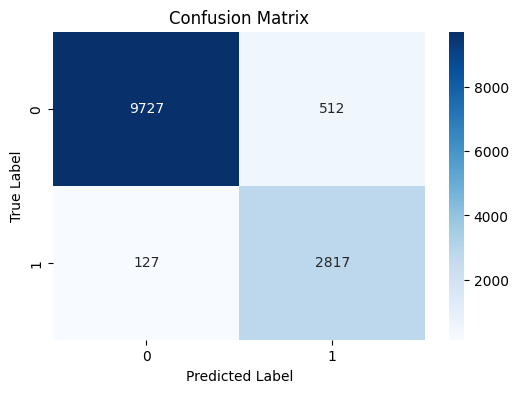


Top 10 Features:
                   feature     importance
61       purchase_next_30d  784145.789062
45          events_last_7d   30485.546755
12         events_last_30d    4560.153981
63   future_30d_spend_true    3476.747304
77             days_active    1572.711683
53          momentum_delta     785.252602
100    search_intensity_7d     557.472799
111             gn_short_3     511.041603
65             true_uplift     406.646300
21          events_last_1h     379.202803


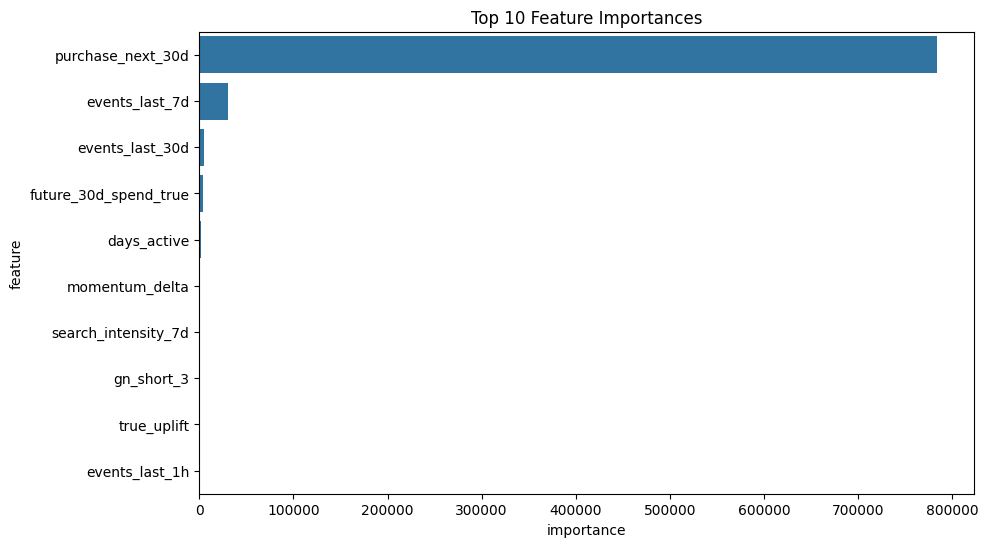


✅ Saved model to C:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\Models\Purchase Likelihood\outputs\model_7DAYS.joblib


In [5]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump
from pathlib import Path

# Load data
df = pd.read_csv('C:\\Users\\abhin\\Desktop\\Projects\\FinTech Projects\\Prophet\\Dataset\\clv_7d_ready_dataset.csv')  # Replace with your full file path

# Drop ID/date columns (add feature eng if needed)
drop_cols = ['person', 'anchor_time', 'became_member_on', 'anchor_time_parsed']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Categorical columns (LGBM handles natively)
cat_cols = ['gender', 'behavior_segment', 'loyalty_tier', 'recency_bucket']
cat_cols = [c for c in cat_cols if c in df.columns]  # keep only existing
for col in cat_cols:
    df[col] = df[col].astype('category')

# Target
target = 'purchase_next_7d'
if target not in df.columns:
    raise ValueError(f"Target '{target}' not found. Check column name.")

features = [col for col in df.columns if col != target]
X = df[features]
y = df[target]

# Split (stratified for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Imbalance handling
pos_ratio = y_train.mean()
scale_pos_weight = (1 - pos_ratio) / pos_ratio if pos_ratio > 0 else 1.0

# LightGBM model parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42,
}
# Prepare datasets (pass categorical_feature by name)
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
valid_data = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_cols, reference=train_data)

# Train the model (results in an lgb.Booster object)
model_booster = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

# Predictions
# Use the trained booster model for predictions
y_pred_proba = model_booster.predict(X_test, num_iteration=model_booster.best_iteration)
y_pred = (y_pred_proba > 0.5).astype(int)

# Metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

# Precision@Top5%
n_test = len(y_test)
k = max(1, int(0.05 * n_test))
# Ensure correct indexing for pandas Series (y_test is a Series)
top_k_idx = np.argsort(y_pred_proba)[::-1][:k]
prec_top5 = y_test.iloc[top_k_idx].sum() / k

# Print metrics
print("=== Model Metrics ===")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")
print(f"Precision@Top5%: {prec_top5:.4f}")
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature Importance (top 10)
feat_names = model_booster.feature_name()
importance = pd.DataFrame({
    'feature': feat_names,
    'importance': model_booster.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(10)
print("\nTop 10 Features:")
print(importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.show()


# ==============================================================================
# 🎯 FIX: Convert lgb.Booster to Scikit-learn LGBMClassifier for joblib compatibility
# ==============================================================================

# Initialize a Scikit-learn wrapper object and link the trained booster
model_sklearn = lgb.LGBMClassifier()
model_sklearn.set_params(**params) # Set parameters
model_sklearn._Booster = model_booster # Link the trained model data

# Define the path using pathlib
try:
    base_path = Path(r"C:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\Models\Purchase Likelihood\outputs")
    
    # Ensure the directory exists
    base_path.mkdir(parents=True, exist_ok=True)
    
    # Construct the full model path
    model_path = base_path / "model_7DAYS.joblib"
    
    # Dump the Scikit-learn compatible object
    dump(model_sklearn, model_path)
    
    print('\n✅ Saved model to', model_path)

except Exception as e:
    print(f"\n❌ Error saving model: {e}")

# ==============================================================================

In [29]:
# Purchase Likelihood — data load, preprocessing, and modeling
# Loads the synthetic dataset and fits a separate LightGBM classifier
# for each purchase window: 1d, 7d, 30d, 90d.

import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score
)
from joblib import dump
from lightgbm import LGBMClassifier

# sklearn OneHotEncoder compatibility: import here but instantiate conditionally
from sklearn.preprocessing import OneHotEncoder

# CONFIG
CSV_PATH = Path("..") / ".." / "Dataset" / "synthetic_prophet_dataset_v2.csv"
if not CSV_PATH.exists():
    CSV_PATH = Path("Dataset") / "synthetic_prophet_dataset_v2.csv"

# Default SAMPLE_N reduced for quicker runs; set to None to use full dataset
SAMPLE_N = None
SEED = 2025
OUTPUT_DIR = Path(".") / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Provided train-window positive rates (use these to compute class weighting)
# These are the rates you supplied (positives / N):
label_rate_map = {
    'purchase_next_1d': 0.0406,
    'purchase_next_7d': 0.2103,
    'purchase_next_30d': 0.491,
    'purchase_next_90d': 0.752,
    'churn_30d': 0.0968,
}

print('Using CSV:', CSV_PATH)

# Load
use_kwargs = {}
if SAMPLE_N is not None:
    use_kwargs["nrows"] = SAMPLE_N

df = pd.read_csv(CSV_PATH, parse_dates=["anchor_time"], **use_kwargs)
print('Loaded rows:', len(df))

# Ensure temporal ordering for time-based splits
df = df.sort_values('anchor_time').reset_index(drop=True)

# Confirm identity column is not used as feature
if 'person' not in df.columns:
    print('Warning: `person` column not found in dataset')
else:
    print('`person` column present; it will be excluded from features (identity dropped)')

# Target labels to model
label_cols = [c for c in [
    'purchase_next_1d','purchase_next_7d','purchase_next_30d','purchase_next_90d'
] if c in df.columns]
print('Labels found:', label_cols)

# Basic preprocessing and feature selection
# Drop identifier/time columns and label columns to form feature set
# Keep `anchor_time` in df for temporal splitting, but exclude from features
drop_cols = ['person'] + label_cols + ['clv_next_90d','churn_30d','ad_exposure_next7','true_uplift']
candidate_features = [c for c in df.columns if c not in drop_cols and c != 'anchor_time']
print('Candidate features count:', len(candidate_features))

# Split features by dtype
numeric_features = [c for c in candidate_features if pd.api.types.is_numeric_dtype(df[c])]
categorical_features = [c for c in candidate_features if c not in numeric_features]
print('Numeric features:', len(numeric_features), 'Categorical features:', len(categorical_features))

# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale", StandardScaler()),
])

# OneHotEncoder compatibility: some sklearn versions use `sparse`, newer use `sparse_output`
try:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse=False)
except TypeError:
    ohe_instance = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_transformer = Pipeline([
    ("impute", SimpleImputer(strategy='constant', fill_value='missing')),
    ("ohe", ohe_instance)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", cat_transformer, categorical_features),
    ],
    remainder='drop'
)

# Create temporal train/val/test indices (70/15/15 by time)
n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)
# ensure at least one sample in each split
n_val = max(n_val, 1)
if n - (n_train + n_val) < 1:
    # reduce train to ensure test has at least one
    n_train = max(n - n_val - 1, 1)

train_idx = np.arange(0, n_train)
val_idx = np.arange(n_train, n_train + n_val)
test_idx = np.arange(n_train + n_val, n)
print(f'Temporal split sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

# Training loop for each label
results = {}
for label in label_cols:
    print('\n--- Training for label:', label, '---')
    # Prepare X,y
    X = df[candidate_features].copy()
    y = df[label].astype(int).copy()

    # quick sanity: if label is constant, skip
    if y.nunique() <= 1:
        print('Skipping', label, '- only one class present')
        continue

    # temporal split (no randomness)
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    print('Train/Val/Test shapes:', X_train.shape, X_val.shape, X_test.shape)

    # fit preprocessor on training data and transform
    preprocessor.fit(X_train)
    X_train_t = preprocessor.transform(X_train)
    X_val_t = preprocessor.transform(X_val)
    X_test_t = preprocessor.transform(X_test)

    # compute scale_pos_weight for this label using provided rates
    rate = label_rate_map.get(label)
    if rate is None:
        # fallback: compute empirical rate from training set
        emp_rate = float(y_train.mean()) if len(y_train)>0 else 0.5
        print(f'No provided rate for {label}; using empirical train rate {emp_rate:.4f} to derive weights')
        rate = emp_rate

    if rate <= 0:
        scale_pos_weight = 1.0
    else:
        scale_pos_weight = float((1.0 - rate) / rate)

    print(f'Using scale_pos_weight={scale_pos_weight:.4f} for label {label} (rate={rate:.4f})')

    # model using LightGBM trained on preprocessed arrays so eval_set works correctly
    clf = LGBMClassifier(
        n_estimators=200,
        objective='binary',
        random_state=SEED,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        class_weight=None
    )

    # fit with early stopping on validation set
    try:
        clf.fit(
            X_train_t, y_train,
            eval_set=[(X_val_t, y_val)],
            early_stopping_rounds=50,
            verbose=False
        )
    except TypeError:
        # some lightgbm versions expect `callbacks` instead; fall back to simpler fit
        clf.fit(X_train_t, y_train)

    # predict on test
    y_pred = clf.predict(X_test_t)
    try:
        y_proba = clf.predict_proba(X_test_t)[:,1]
    except Exception:
        y_proba = None

    # metrics
    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_test, y_pred))
    metrics['precision'] = float(precision_score(y_test, y_pred, zero_division=0))
    metrics['recall'] = float(recall_score(y_test, y_pred, zero_division=0))
    metrics['f1'] = float(f1_score(y_test, y_pred, zero_division=0))

    if y_proba is not None and len(np.unique(y_test))>1:
        try:
            metrics['roc_auc'] = float(roc_auc_score(y_test, y_proba))
        except Exception:
            metrics['roc_auc'] = None
        try:
            metrics['pr_auc'] = float(average_precision_score(y_test, y_proba))
        except Exception:
            metrics['pr_auc'] = None
    else:
        metrics['roc_auc'] = None
        metrics['pr_auc'] = None

    # confusion (handle edge cases)
    try:
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        metrics.update({'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)})
    except Exception:
        cm = confusion_matrix(y_test, y_pred)
        metrics.update({'conf_matrix': cm.tolist()})

    print('Metrics:', metrics)
    results[label] = metrics

    # wrap the fitted preprocessor and classifier into a Pipeline for saving
    final_pipeline = Pipeline([('pre', preprocessor), ('clf', clf)])

    # save model
    model_path = OUTPUT_DIR / f"model_{label}.joblib"
    dump(final_pipeline, model_path)
    print('Saved model to', model_path)

# Save metrics summary
metrics_df = pd.DataFrame(results).T
metrics_df.to_csv(OUTPUT_DIR / 'metrics_summary.csv')
print('\nAll done. Metrics summary saved to', OUTPUT_DIR / 'metrics_summary.csv')
print(metrics_df)

print("Run HPT for 30D and 90D on this cell material only")


Using CSV: ..\..\Dataset\synthetic_prophet_dataset_v2.csv
Loaded rows: 150000
Loaded rows: 150000
`person` column present; it will be excluded from features (identity dropped)
Labels found: ['purchase_next_1d', 'purchase_next_7d', 'purchase_next_30d', 'purchase_next_90d']
Candidate features count: 62
Numeric features: 58 Categorical features: 4
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
`person` column present; it will be excluded from features (identity dropped)
Labels found: ['purchase_next_1d', 'purchase_next_7d', 'purchase_next_30d', 'purchase_next_90d']
Candidate features count: 62
Numeric features: 58 Categorical features: 4
Temporal split sizes -> train: 105000, val: 22500, test: 22500

--- Training for label: purchase_next_1d ---
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
Using scale_pos_weight=23.6305 for label purchase_next_1d (rate=0.

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.8704, 'precision': 0.1669421487603306, 'recall': 0.04019100676482292, 'f1': 0.06478511866581142, 'roc_auc': 0.5655548370666958, 'pr_auc': 0.14208302764376057, 'tn': 19483, 'fp': 504, 'fn': 2412, 'tp': 101}
Saved model to outputs\model_purchase_next_1d.joblib

--- Training for label: purchase_next_7d ---
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
Using scale_pos_weight=3.7551 for label purchase_next_7d (rate=0.2103)
Using scale_pos_weight=3.7551 for label purchase_next_7d (rate=0.2103)
[LightGBM] [Info] Number of positive: 10615, number of negative: 94385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12144
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 1058
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.101095 -> initscore=-2.185114
[LightGBM] [Info] Start t

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.5056444444444445, 'precision': 0.6491935483870968, 'recall': 0.014378851478074484, 'f1': 0.028134556574923548, 'roc_auc': 0.5930863168747782, 'pr_auc': 0.573481491607886, 'tn': 11216, 'fp': 87, 'fn': 11036, 'tp': 161}
Saved model to outputs\model_purchase_next_7d.joblib

--- Training for label: purchase_next_30d ---
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
Using scale_pos_weight=1.0367 for label purchase_next_30d (rate=0.4910)
Using scale_pos_weight=1.0367 for label purchase_next_30d (rate=0.4910)
[LightGBM] [Info] Number of positive: 35751, number of negative: 69249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12144
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 1058
[LightGBM] [Info] [binary:

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.3722666666666667, 'precision': 0.9835676103741833, 'recall': 0.261349886895681, 'f1': 0.41296758104738157, 'roc_auc': 0.8171964073945946, 'pr_auc': 0.9569014035012675, 'tn': 3408, 'fp': 83, 'fn': 14041, 'tp': 4968}
Saved model to outputs\model_purchase_next_30d.joblib

--- Training for label: purchase_next_90d ---
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
Train/Val/Test shapes: (105000, 62) (22500, 62) (22500, 62)
Using scale_pos_weight=0.3298 for label purchase_next_90d (rate=0.7520)
Using scale_pos_weight=0.3298 for label purchase_next_90d (rate=0.7520)
[LightGBM] [Info] Number of positive: 69339, number of negative: 35661
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12144
[LightGBM] [Info] Number of data points in the train set: 105000

c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\abhin\Desktop\Projects\FinTech Projects\Prophet\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Metrics: {'accuracy': 0.7568888888888889, 'precision': 0.9987659653236256, 'recall': 0.7481166520312428, 'f1': 0.8554592537786704, 'roc_auc': 0.9585786888913036, 'pr_auc': 0.9982047167135989, 'tn': 843, 'fp': 20, 'fn': 5450, 'tp': 16187}
Saved model to outputs\model_purchase_next_90d.joblib

All done. Metrics summary saved to outputs\metrics_summary.csv
                   accuracy  precision    recall        f1   roc_auc  \
purchase_next_1d   0.870400   0.166942  0.040191  0.064785  0.565555   
purchase_next_7d   0.505644   0.649194  0.014379  0.028135  0.593086   
purchase_next_30d  0.372267   0.983568  0.261350  0.412968  0.817196   
purchase_next_90d  0.756889   0.998766  0.748117  0.855459  0.958579   

                     pr_auc       tn     fp       fn       tp  
purchase_next_1d   0.142083  19483.0  504.0   2412.0    101.0  
purchase_next_7d   0.573481  11216.0   87.0  11036.0    161.0  
purchase_next_30d  0.956901   3408.0   83.0  14041.0   4968.0  
purchase_next_90d  0.998205